In [1]:
from aqua.diagnostics import ssh_variability_compute, ssh_variability_plot
from aqua import Reader
import xarray as xr
import numpy as np
import pandas as pd
from pathlib import Path
# import gc

/home/a/a270260/.conda/envs/aqua-dev/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/home/a/a270260/.conda/envs/aqua-dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def init_state(template: xr.DataArray) -> dict:
    """
    Initialize empty state from a template DataArray (e.g. first slice)
    """
    zero_array = xr.zeros_like(template.isel(time=0)).compute()
    return {
        "count":           0,
        "start_timestamp": template.isel(time=0).time.values,
        "end_timestamp":   template.isel(time=0).time.values,
        "m1":              zero_array.copy(),             
        "m2":              zero_array.copy(),
        "m3":              zero_array.copy(),
        "m4":              zero_array.copy(),
    }

def save_state(state: dict, var: str ,path: str = "./"):
    """
    Saving the state
    """
    start_str = pd.Timestamp(state["start_timestamp"]).strftime("%Y-%m-%d")
    end_str   = pd.Timestamp(state["end_timestamp"]).strftime("%Y-%m-%d")
    
    ds = xr.Dataset({
        f"{var}_m1":       state["m1"].drop_vars("time", errors="ignore"),
        f"{var}_m2":       state["m2"].drop_vars("time", errors="ignore"),
        f"{var}_m3":       state["m3"].drop_vars("time", errors="ignore"),
        f"{var}_m4":       state["m4"].drop_vars("time", errors="ignore"),
    })
    ds.attrs["start_timestamp"] = start_str
    ds.attrs["end_timestamp"]   = end_str
    ds.attrs["count"]           = state["count"]
    
    dir_path = Path(path)
    dir_path.mkdir(parents=True, exist_ok=True)
    
    filename = f"{path}/welford_state_{start_str}_to_{end_str}.nc"
    ds.to_netcdf(filename)

def load_state(filename: str, var: str) -> dict:
    """
    Loading the state
    """
    ds = xr.open_dataset(filename)
    return {
        "count":           ds.attrs["count"],
        "start_timestamp": pd.Timestamp(ds.attrs["start_timestamp"]),
        "end_timestamp":   pd.Timestamp(ds.attrs["end_timestamp"]),
        "m1":              ds[f"{var}_m1"].rename(var),
        "m2":              ds[f"{var}_m2"].rename(var),
        "m3":              ds[f"{var}_m3"].rename(var),
        "m4":              ds[f"{var}_m4"].rename(var),
    }

def welford_std(state: dict, ddof=0) -> xr.DataArray:
    """
    Compute std from current state
    """
    return np.sqrt(state["m2"] / (state["count"] - ddof))

def welford_statistics(var: str, 
                     data: xr.DataArray=None, 
                     state: dict=None, 
                     dim: str="time",
                     statistics: dict = {"variance": True, "skewness_kurtosis": True},
                     ddof: int=0, 
                     fillnan: bool=True, 
                     outputdir: str="./", 
                     state_save: bool=True):
    """
    Welford's online variance along a given dimension.
    This can be made more generalized for all other dimensions.
    
    ddof=1: sample variance (unbiased, matches np.var(ddof=1))
    ddof=0: population variance
    """
    # TODO: 
    #      Test Skipna vs fillna(0)
    #      For now, fillna(0) is used in order to compare the results with 
    #      Skipna
    if state==None:
        state = init_state(data)

    count = state["count"]
    start_timestamp = state["start_timestamp"] 
    end_timestamp = state["end_timestamp"]

    # fill NaN's as ZEROS
    if fillnan:
        m1 = state["m1"].fillna(0)
        m2 = state["m2"].fillna(0)
        m3 = state["m3"].fillna(0)
        m4 = state["m4"].fillna(0)
    else:
        m1 = state["m1"]
        m2 = state["m2"]
        m3 = state["m3"]
        m4 = state["m4"]

    # TODO:
    #      Which chunk to be loaded
    #      Either month or each Timestamp
    #      In some case loading monthly chunk is slower than loading
    #      each Timestamp
    for month_label, ds_month in data.resample(time="MS"):
        ds_month.load() 
        # iterates over the leading (time) dimension
        for x in ds_month:          
            # x.load()
            count += 1
            if fillnan: x = x.fillna(0) # with fillnan as ZEROS    
            # compute delta ONCE — reused in both updates
            delta   = (x - m1).compute()   # diff from OLD mean
            delta_n = delta / count          # fractional adjustment
            if statistics["variance"]:
                delta_n2 = delta_n * delta_n
                term1   = delta * delta_n * (count - 1)

                if statistics["skewness_kurtosis"]:
                    # M4 uses old m2 and old m3
                    m4 = m4 + (term1 * delta_n2 * (count * count - 3 * count + 3)
                               + 6 * delta_n2 * m2
                               - 4 * delta_n  * m3)
                    # M3 uses old m2
                    m3 = m3 + (term1 * delta_n * (count - 2)
                               - 3 * delta_n * m2)

            # M2 and M1 last
            if statistics["variance"]: m2 = m2 + term1
            m1 = m1 + delta_n
        
    nan_template = xr.full_like(data.isel({dim: 0}).compute(), fill_value=float("nan"))

    if state_save:
        state = {"count": count, "start_timestamp": start_timestamp, "end_timestamp": x.time.values, "m1": m1, "m2": m2, "m3": m3, "m4": m4}
        save_state(state=state, var=var, path=outputdir)
        
    if count < 2:
        return {k: nan_template for k in ("mean", "variance", "skewness", "kurtosis")}

    variance = m2 / (count - ddof)

    # FIX 2: Clip m2 to avoid RuntimeWarnings from floating-point noise
    m2_safe = m2.clip(min=0)
    if statistics["variance"] is True and statistics["skewness_kurtosis"] is True:
        skewness = xr.where(
            (m2 > 0) & (count >= 3),
            (np.sqrt(count) * m3) / (m2_safe ** 1.5),
            nan_template,
        )

        kurtosis = xr.where(
            (m2 > 0) & (count >= 4),
            (count * m4) / (m2_safe * m2_safe) - 3.0,
            nan_template,
        )
    if statistics["variance"] is True and statistics["skewness_kurtosis"] is True:
        return {
            "mean":     m1,
            "variance": variance,
            "skewness": skewness,
            "kurtosis": kurtosis,
        }
    else:
        return {
            "mean":     m1,
            "variance": variance,
        }

In [3]:
# # Outputdir
# outputdir = "./AVISO_ssh_higher_moments" 
# var = "adt"
# startdate_0="1993-01-01"; enddate_0="1994-12-31"; # Test 00
# startdate_1="1995-01-01"; enddate_1="1995-12-31"; # Test 01
# startdate=startdate_0; enddate=enddate_1 # Total interval
# statistics = {"variance": True, "skewness_kurtosis": True}

In [4]:
# Outputdir
outputdir = "./AVISO_ssh_higher_moments" 
var = "adt"
startdate_0="1993-01-01"; enddate_0="1999-12-31"; # Test 00
startdate_1="2000-01-01"; enddate_1="2024-12-31"; # Test 01
startdate=startdate_0; enddate=enddate_1 # Total interval
statistics = {"variance": True, "skewness_kurtosis": True}

In [5]:
## Test 00: AVISO from 1993-01-01 to 1994-12-31
dataset_dict_ref = {"catalog": "obs", "model": "AVISO", "exp":"vDT2024", "source":"daily-zarr"}
reader0 = Reader(**dataset_dict_ref, startdate=startdate_0, enddate=enddate_0, fix=True)
data0 = reader0.retrieve()
data0 = data0[var]

2026-04-08 17:56:16 :: Regridder :: WARNING  -> Source grid path not found. Please provide a dataset.
2026-04-08 17:56:16 :: Reader :: WARNING  -> Issues in the Regridder() init: trying with data
2026-04-08 17:56:55 :: Reader :: WARNING  -> Variable crs has no units!
2026-04-08 17:56:55 :: Reader :: WARNING  -> Variable flag_ice has no units!
2026-04-08 17:56:55 :: Reader :: WARNING  -> Variable lat_bnds has no units!
2026-04-08 17:56:55 :: Reader :: WARNING  -> Variable lon_bnds has no units!


In [6]:
## Test 01: AVISO data from 1993-01-01 to 1995-12-31
dataset_dict_ref = {"catalog": "obs", "model": "AVISO", "exp":"vDT2024", "source":"daily-zarr"}
reader1 = Reader(**dataset_dict_ref, startdate=startdate_1, enddate=enddate_1, fix=True)
data1 = reader1.retrieve()
data1 = data1[var]

2026-04-08 17:56:55 :: Regridder :: WARNING  -> Source grid path not found. Please provide a dataset.
2026-04-08 17:56:55 :: Reader :: WARNING  -> Issues in the Regridder() init: trying with data
2026-04-08 17:57:01 :: Reader :: WARNING  -> Variable crs has no units!
2026-04-08 17:57:01 :: Reader :: WARNING  -> Variable flag_ice has no units!
2026-04-08 17:57:01 :: Reader :: WARNING  -> Variable lat_bnds has no units!
2026-04-08 17:57:01 :: Reader :: WARNING  -> Variable lon_bnds has no units!


In [7]:
## AVISO data from 1993-01-01 to 1995-12-31
dataset_dict_ref = {"catalog": "obs", "model": "AVISO", "exp":"vDT2024", "source":"daily-zarr"}
reader = Reader(**dataset_dict_ref, startdate=startdate, enddate=enddate, fix=True)
data = reader.retrieve()
data = data[var]

2026-04-08 17:57:02 :: Regridder :: WARNING  -> Source grid path not found. Please provide a dataset.
2026-04-08 17:57:02 :: Reader :: WARNING  -> Issues in the Regridder() init: trying with data
2026-04-08 17:57:07 :: Reader :: WARNING  -> Variable crs has no units!
2026-04-08 17:57:07 :: Reader :: WARNING  -> Variable flag_ice has no units!
2026-04-08 17:57:07 :: Reader :: WARNING  -> Variable lat_bnds has no units!
2026-04-08 17:57:07 :: Reader :: WARNING  -> Variable lon_bnds has no units!


In [8]:
%%time
# TEST 00
# STD from 1993-01-01 to 1994-12-31
welford_stats0 = welford_statistics(data=data0, var=var, fillnan=False, statistics=statistics, state_save=True, outputdir=outputdir)

CPU times: user 1min 43s, sys: 46.1 s, total: 2min 29s
Wall time: 2min 35s


In [9]:
state_0_path = f"{outputdir}/welford_state_{startdate_0}_to_{enddate_0}.nc"
state0 = load_state(state_0_path, var=var)

In [10]:
%%time
# STD from 1993-01-01 to 1995-12-31 
welford_stats = welford_statistics(data=data1, state=state0, var=var, fillnan=False, statistics=statistics, state_save=True, outputdir=outputdir)

CPU times: user 6min 6s, sys: 2min 42s, total: 8min 49s
Wall time: 9min 15s


In [11]:
std1 = np.sqrt(welford_stats["variance"])

In [12]:
%%time
### Kurtosis
mean = data.mean(dim='time', skipna=False).compute()
std = data.std(dim='time', skipna=False).compute()
kurtosis = ((data - mean)**4).mean(dim='time') / (std**4)
excess_kurtosis = kurtosis - 3

CPU times: user 3min 2s, sys: 3min 45s, total: 6min 48s
Wall time: 6min 50s


In [13]:
excess_kurtosis.load()

<xarray.DataArray 'adt' (lat: 720, lon: 1440)> Size: 8MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(720, 1440))
Coordinates:
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
Attributes:
    comment:        The absolute dynamic topography is the sea surface height...
    grid_mapping:   crs
    long_name:      Absolute dynamic topography
    standard_name:  sea_surface_height_above_geoid
    units:          m
    AQUA_model:     AVISO
    AQUA_exp:       vDT2024
    AQUA_source:    daily-zarr
    AQUA_catalog:   obs
    AQUA_version:   1.0.0a4

In [20]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

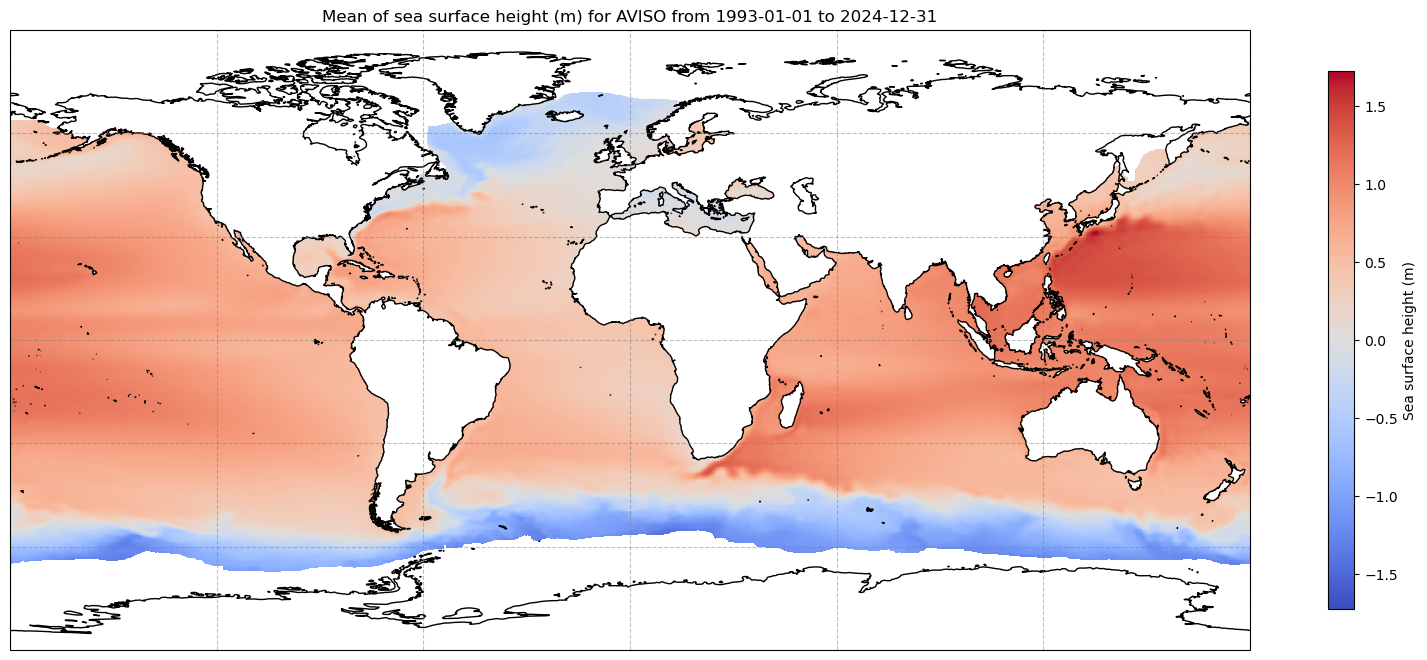

In [21]:
fig = plt.figure(figsize=(20, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

welford_stats["mean"].plot(
    ax=ax, 
    transform=ccrs.PlateCarree(), 
    cmap='coolwarm',
    #vmin=,  
    #vmax=,  
    cbar_kwargs={"shrink": 0.7, "label": "Sea surface height (m)"}
)

ax.coastlines(resolution='50m', color='black', linewidth=1)
# ax.add_feature(cfeature.BORDERS, linestyle=':')
# ax.add_feature(cfeature.STATES, edgecolor='gray')
ax.gridlines(draw_labels=False, color='gray', alpha=0.5, linestyle='--')

plt.title(f"Mean of sea surface height (m) for {dataset_dict_ref["model"]} from {startdate} to {enddate}")
# plt.savefig(f"./png/mean_AVISO_{startdate}_to_{enddate}.png")
plt.show()

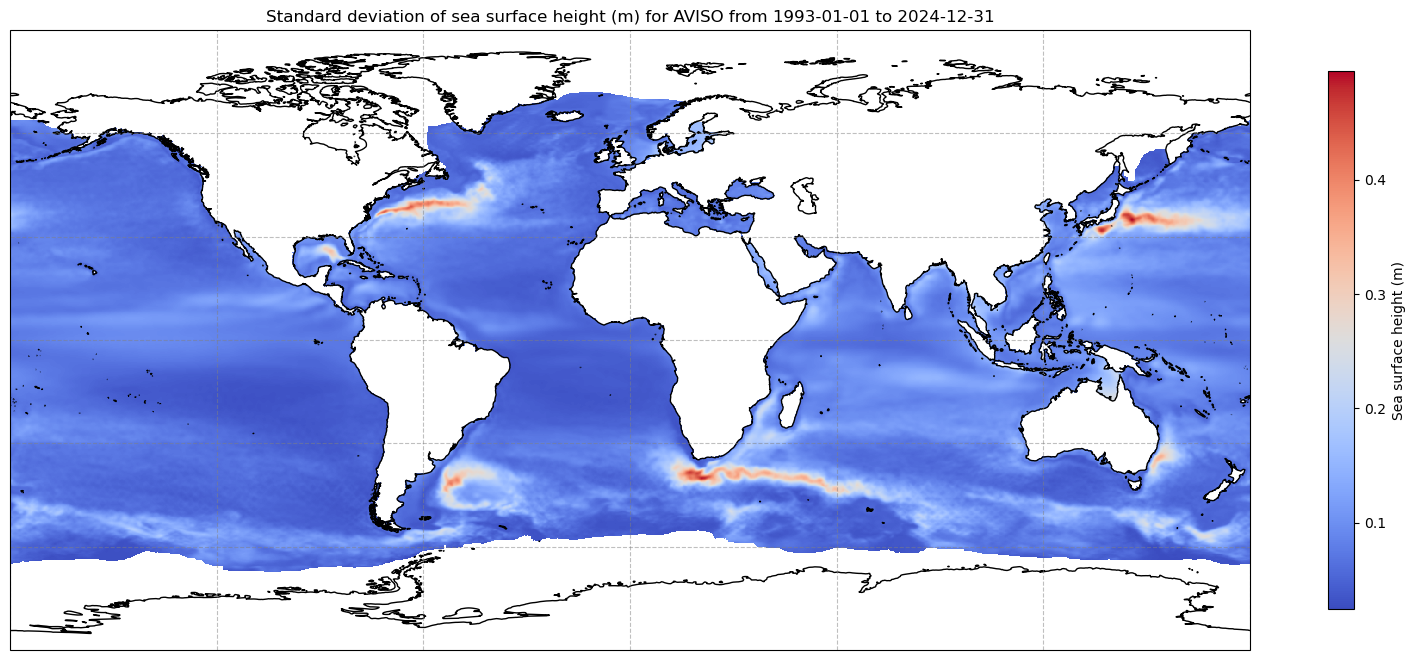

In [28]:
fig = plt.figure(figsize=(20, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

std1.plot(
    ax=ax, 
    transform=ccrs.PlateCarree(), 
    cmap='coolwarm',
    # vmin=0,  
    # vmax=0.7,  
    cbar_kwargs={"shrink": 0.7, "label": "Sea surface height (m)"}
)

ax.coastlines(resolution='50m', color='black', linewidth=1)
# ax.add_feature(cfeature.BORDERS, linestyle=':')
# ax.add_feature(cfeature.STATES, edgecolor='gray')
ax.gridlines(draw_labels=False, color='gray', alpha=0.5, linestyle='--')

plt.title(f"Standard deviation of sea surface height (m) for {dataset_dict_ref["model"]} from {startdate} to {enddate}")
# plt.savefig(f"./png/std_AVISO_{startdate}_to_{enddate}.png")
plt.show()

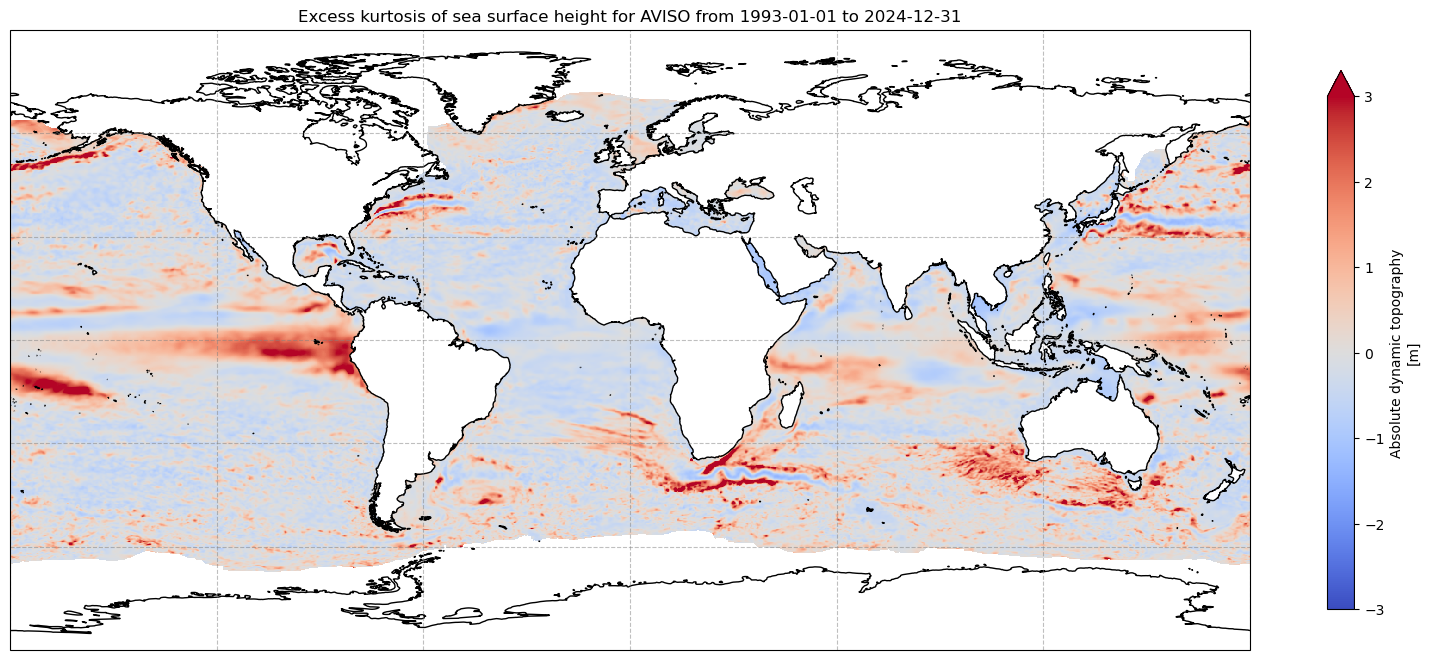

In [46]:
fig = plt.figure(figsize=(20, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

welford_stats["kurtosis"].plot(
    ax=ax, 
    transform=ccrs.PlateCarree(), 
    cmap='coolwarm',
    vmin=-3,  
    # vmax=3,  
    cbar_kwargs={"shrink": 0.7}
)

ax.coastlines(resolution='50m', color='black', linewidth=1)
# ax.add_feature(cfeature.BORDERS, linestyle=':')
# ax.add_feature(cfeature.STATES, edgecolor='gray')
ax.gridlines(draw_labels=False, color='gray', alpha=0.5, linestyle='--')

plt.title(f"Excess kurtosis of sea surface height for {dataset_dict_ref["model"]} from {startdate} to {enddate}")
# plt.savefig(f"./png/Excess_kurtosis_AVISO_{startdate}_to_{enddate}.png")
plt.show()